In [1]:
import numpy as np 
import scipy.stats as sp
import matplotlib.pyplot as plt 
from statsmodels.graphics import tsaplots

In [1]:
from function.VAE import *

In [ ]:
encoder = Encoder(2,2, True)
decoder = Decoder(2,2,True)
prior = VP(2,35)
vae = VAE(encoder, decoder, prior, name_prior = 'vamprior')
vae(np.random.normal(size = (10,2)))

In [5]:
vae.summary()

Model: "vae"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder (Encoder)           multiple                  2410      
                                                                 
 decoder (Decoder)           multiple                  2474      
                                                                 
 VP (VP)                     multiple                  0 (unused)
                                                                 
Total params: 4890 (19.10 KB)
Trainable params: 4884 (19.08 KB)
Non-trainable params: 6 (24.00 Byte)
_________________________________________________________________


Estimation Pf par VAESS : 0.0009033222656250001
Variance de l'estimateur VAESS : 5.553648170638365e-05

In [6]:
import re
def extract_values(filename, value_pattern):
    values = []
    with open(filename, 'r') as f:
        for line in f:
            # Extraire les valeurs spécifiques de la ligne
            line = line.strip('\n')
            match = re.search(value_pattern, line)

            if match:
                values.append(float(match.group(0)))  # Assumes value is in group 1
                # print(match.group(0))
    return np.array(values)

In [51]:
defaillance = extract_values('SSVAE.txt', '0.000..')

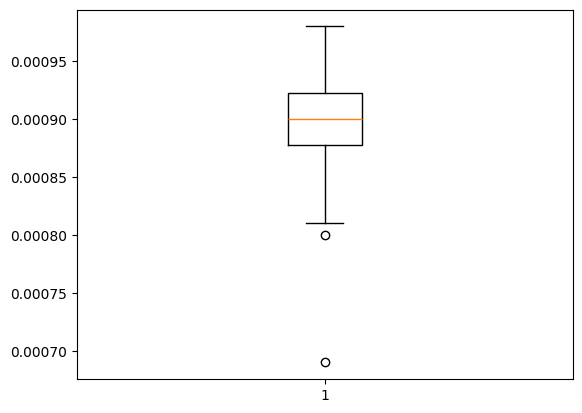

In [54]:
plt.boxplot(defaillance);

In [3]:
def resultat(path, **kwargs):
    arrays = np.load(path)
    chain = arrays['arr_0']
    acceptance = arrays['arr_1']
    ratio = arrays['arr_2']
    return chain, acceptance, ratio

In [8]:
defaillance = extract_values('txtfiles/SSVAE_2.txt', '0.000..')
defaillance.shape

(28,)

#### Etude du cas de dimension 2

In [3]:
dim2 = np.load('Resultats/Dim_2.npz')
dim2.files

['arr_0', 'arr_1', 'arr_2']

In [4]:
chain = dim2['arr_0']
acceptance = dim2['arr_1']
ratio= dim2['arr_2']

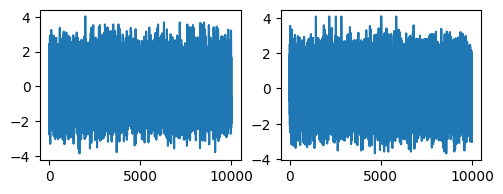

In [76]:
plt.figure(figsize= (15,9))
for i in range(2):
    plt.subplot(4,5, i+1)
    plt.plot(chain[0][:, i])
plt.show()

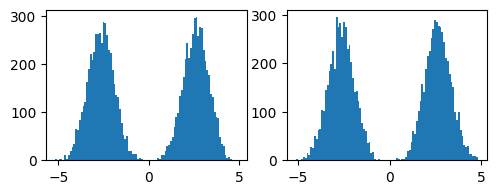

In [77]:
plt.figure(figsize= (15,9))
for i in range(2):
    plt.subplot(4,5, i+1)
    plt.hist(chain[-1][:, i], bins=100)
plt.show()

In [79]:
acceptance.mean(axis=1)

array([0.48666667, 0.46468333, 0.42781667, 0.37693333, 0.3945    ])

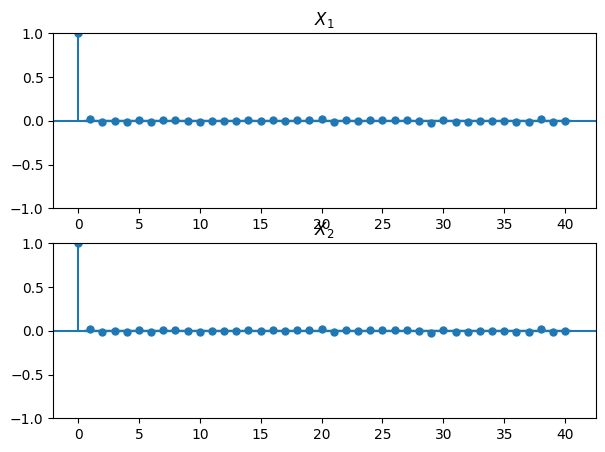

In [80]:
from statsmodels.graphics import tsaplots
fig,ax = plt.subplots(2,int(2/2), figsize = (7,5))
for i in range(int(2/2)):
    tsaplots.plot_acf(chain[-1][:, i], ax = ax[i], title= r"$X_{%i}$"%(i+1))
    tsaplots.plot_acf(chain[-1][:, int(2/2)-1+i], ax = ax[i+1], title= r"$X_{%i}$"%(int(2/2)+i+1))
plt.show()

In [12]:
def four_branch_2d(X, beta = 0, linear = False):
    if linear:
        quant1 = np.expand_dims((X[0]+X[1]) / np.sqrt(2), 1) +beta 
        quant2 = np.expand_dims((-X[0]-X[1])/ np.sqrt(2),1) + beta
        quant3 = np.expand_dims((X[0]-X[1]) / np.sqrt(2) ,1) + beta
        quant4 = np.expand_dims((X[1]-X[0]) / np.sqrt(2) ,1) + beta

        tensor = np.concatenate([quant1, quant2, quant3, quant4], axis =1 )
        minimum = np.min(tensor, axis=1)
    else :
        quant1 = np.expand_dims((X[0]-X[1])**2 /10 - (X[0] + X[1]) / np.sqrt(2) + 3, 1) + beta
        quant2 = np.expand_dims((X[0]-X[1])**2 /10 + (X[0] + X[1]) / np.sqrt(2) + 3,1) + beta
        quant3 = np.expand_dims((X[0]-X[1]) + 7/ np.sqrt(2) ,1) +beta 
        quant4 = np.expand_dims((X[1]-X[0]) + 7/ np.sqrt(2) ,1) + beta

        tensor = np.concatenate([quant1, quant2, quant3, quant4], axis =1 )
        minimum = np.min(tensor, axis=1)

    return -minimum

In [13]:
def construction_grid(xmin, xmax, ymin, ymax, npoints):
    x = np.linspace(xmin, xmax, npoints)
    y = np.linspace(ymin, ymax, npoints)

    
    #grid = np.dstack((X,Y))
    return np.meshgrid(x,y)

pos = construction_grid(-8,8,-8,8, 1000)

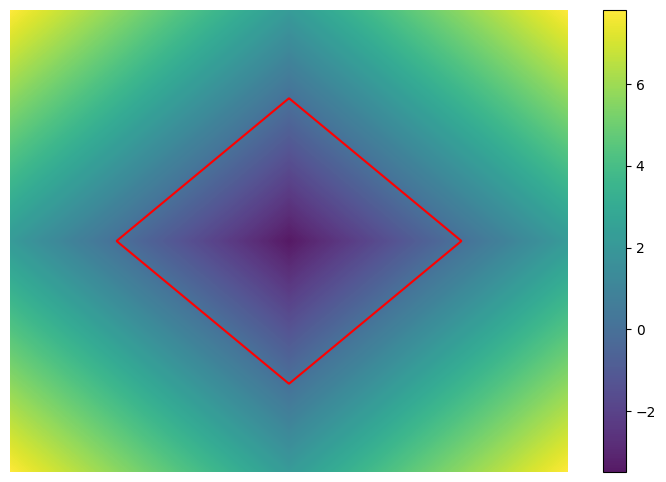

In [73]:
fig, ax = plt.subplots(figsize = (9,6))
pc = ax.pcolormesh(pos[0], pos[1], four_branch_2d(pos, 3.5, linear=True), alpha = 0.9)
fig.colorbar(pc)
cs = ax.contour(pos[0], pos[1], four_branch_2d(pos, 3.5, linear=True), levels = [0], colors = 'red')
# color = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'lightblue']
# for i in range(len(chain)):
#     s = chain[i]
#     ax.scatter(s[:, 0], s[:, 1], c = color[i], s= 3)
# ax.set_title("Linear 4-branch with Vanilla SS + VAE")
ax.axis('off')
plt.show()

In [26]:
type(four_branch_2d(pos, 3.5, linear=True))

numpy.ndarray

A titre d'information : <class 'mpl_toolkits.mplot3d.axes3d.Axes3D'>


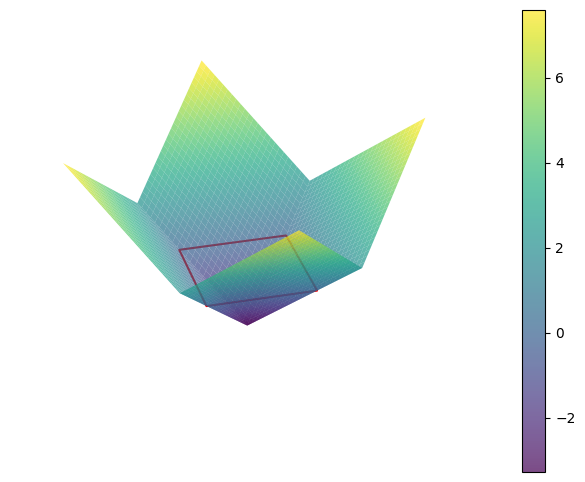

In [65]:

plt.figure(figsize=(13,6))
ax1 = plt.axes(projection="3d")
p = ax1.plot_surface(pos[0], pos[1], four_branch_2d(pos, 3.5, linear=True), cmap = 'viridis', alpha = 0.7)
# ax1.plot_surface(pos[0], pos[1], np.zeros((1000, 1000)), alpha = 0.5)
ax1.contour(pos[0], pos[1], four_branch_2d(pos, 3.5, linear=True), 0, colors = 'red')

plt.colorbar(p)
ax1.grid(False)
ax1.axis('off')
plt.show()

#### Etude du cas de la dimension 10

In [5]:
estimation10 = np.load('Resultats/Estimation_d10.npy')
estimation10.shape

(1,)

In [13]:
cost10 = np.load('Resultats/Cost_d10.npy')
cost10.shape

(50,)

<BarContainer object of 2 artists>

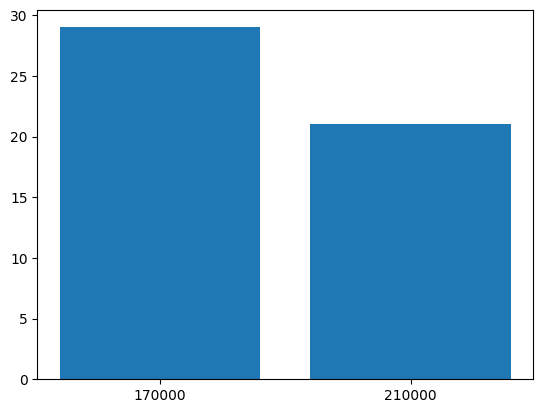

In [25]:
bb = np.unique(cost10, return_counts=True)
plt.bar(bb[0].astype('str'), bb[1])

In [29]:
(f"Le c.o.v pour la dimension 10 avec 35 inputs en Vamprior et 800 gaussienne : {round(estimation10.std() / estimation10.mean(), 5)}")

'Le c.o.v pour la dimension 10 avec 35 inputs en Vamprior et 800 gaussienne : 0.04542'

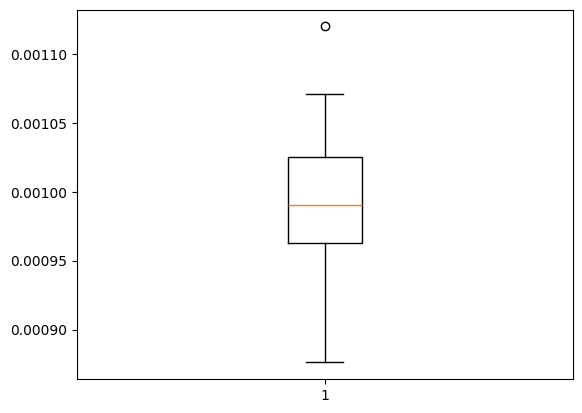

In [30]:
plt.boxplot(estimation10);

In [12]:
Dim_10 = np.load('Resultats/Dim_10.npz')
Dim_10.files

['arr_0', 'arr_1', 'arr_2']

In [13]:
chain10 = Dim_10['arr_0']
acceptance10 = Dim_10['arr_1']
ratio10 = Dim_10['arr_2']

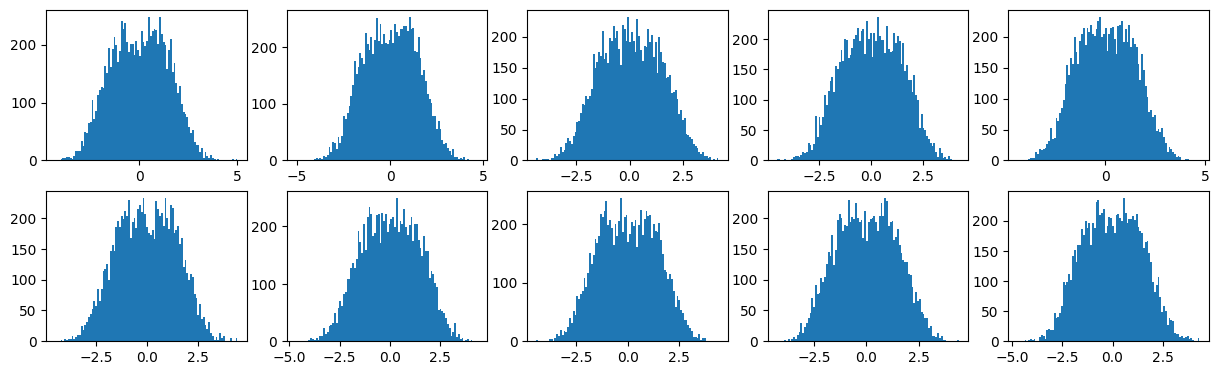

In [14]:
plt.figure(figsize= (15,9))
for i in range(10):
    plt.subplot(4,5, i+1)
    plt.hist(chain10[-1][:, i], bins=100)
plt.show()

In [15]:
acceptance10.mean(axis=1)

array([0.31186667, 0.2425    , 0.20358333, 0.18215   ])

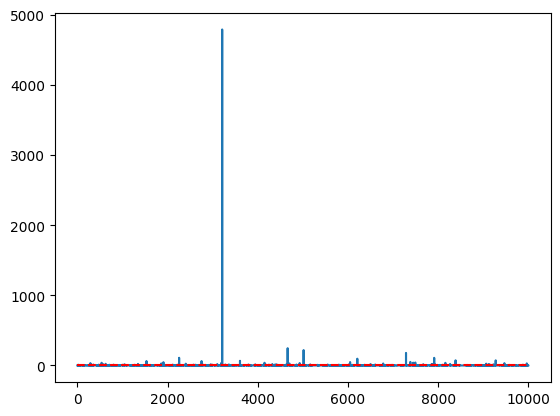

In [17]:
plt.plot(ratio10[-1])
plt.hlines(1, 0 ,10000, 'red', '--')

In [5]:
Dim20 = np.load('Resultats/Dim_20.npz')
Dim20.files

['arr_0', 'arr_1', 'arr_2']

In [6]:
chain20 = Dim20['arr_0']
acceptance20 = Dim20['arr_1']
ratio20 = Dim20['arr_2']

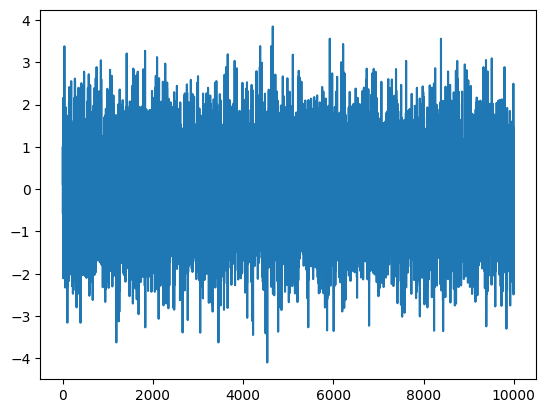

In [7]:
plt.plot(chain20[0][:, 0])

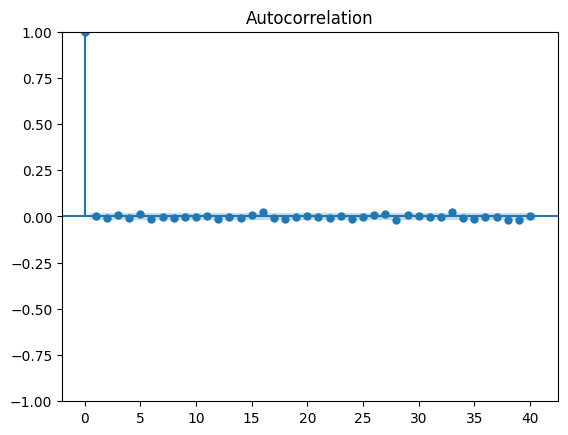

In [11]:
a= tsaplots.plot_acf(chain20[-1][:,0])

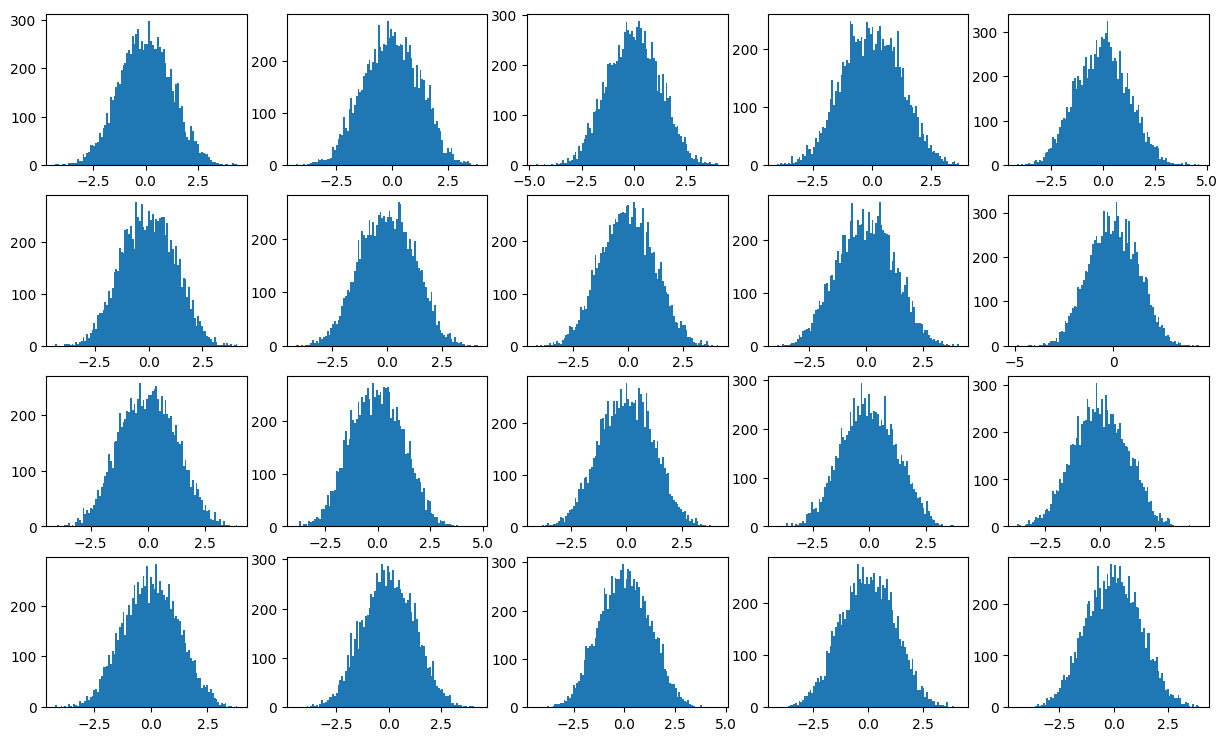

In [37]:
plt.figure(figsize= (15,9))
for i in range(20):
    plt.subplot(4,5, i+1)
    plt.hist(chain20[-1][:, i], bins=100)
plt.show()

In [38]:
acceptance20.mean(axis=1)

array([0.30058333, 0.23373333, 0.20006667, 0.17893333])

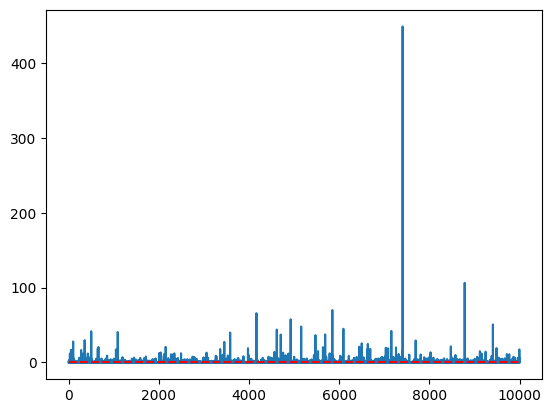

In [39]:
plt.plot(ratio20[-1])
plt.hlines(1, 0, 10000, colors='red', linestyles= '--')

In [33]:
estimation20 = np.load('Resultats/Estimation_d20.npy')
estimation20

array([0.00098477, 0.00107227, 0.00098867, 0.00103477, 0.00099805,
       0.00101328, 0.00105   , 0.00099609, 0.00109102, 0.00109414])

#### Etude du cas de la dimension 50

In [40]:
Dim50 = np.load('Resultats/Dim_50.npz')
Dim50.files

['arr_0', 'arr_1', 'arr_2']

In [41]:
chain50 = Dim50['arr_0']
acceptance50 = Dim50['arr_1']
ratio50 = Dim50['arr_2']

In [42]:
acceptance50.mean(axis= 1)

array([0.29903333, 0.22831667, 0.19258333, 0.1776    ])

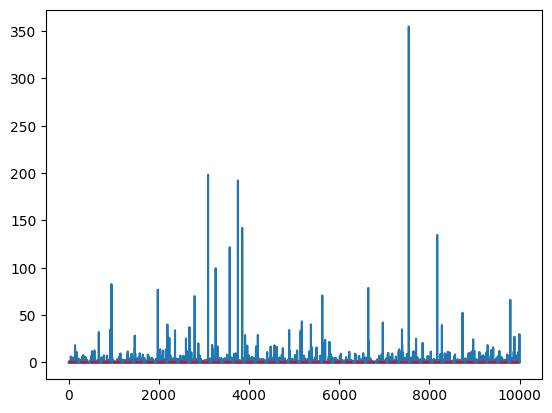

In [44]:
plt.plot(ratio50[-1])
plt.hlines(1, 0, 10000, 'red', '--')

### Etude du cas de la dimension 70

In [45]:
Dim70 = np.load('Resultats/Dim_70.npz')
Dim70.files

['arr_0', 'arr_1', 'arr_2']

In [ ]:
chain70 = Dim70['arr_0']

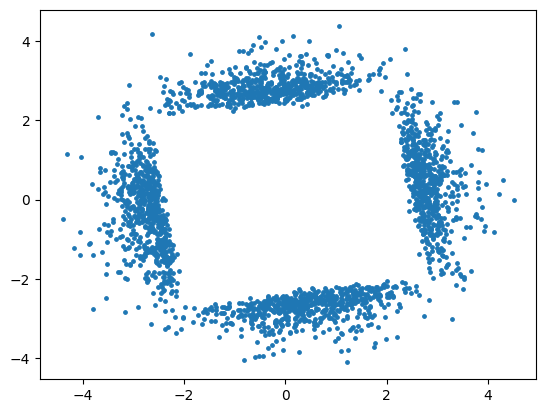

In [59]:
from sklearn.decomposition import PCA
acp = PCA(2)
linear_decomp = acp.fit_transform(sample_threshold)
plt.scatter(linear_decomp[:, 0], linear_decomp[:, 1], s = 6)

[0.25094577 0.20478229 0.26173532 0.05423424 0.22830237] 50


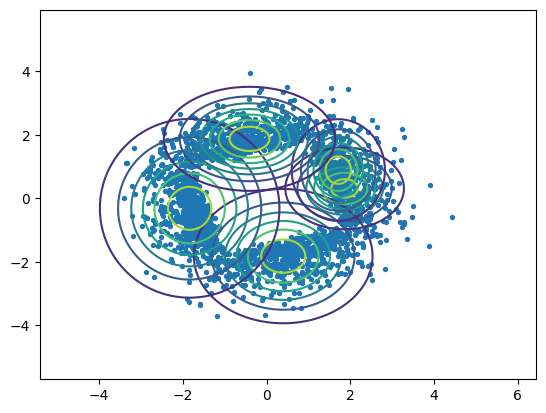

In [87]:
from function.EM import *
prior = MoGPrior(2, 5)
w_t, mu_t, sigma2_t, n_iter = EM(linear_decomp, prior, 50, 1e-2)
print(w_t, n_iter)
mixture_plot(linear_decomp, w_t, mu_t, sigma2_t, min(linear_decomp[:,0])-2, max(linear_decomp[:,0])+2,
              min(linear_decomp[:,1])-2, max(linear_decomp[:,1])+2 )

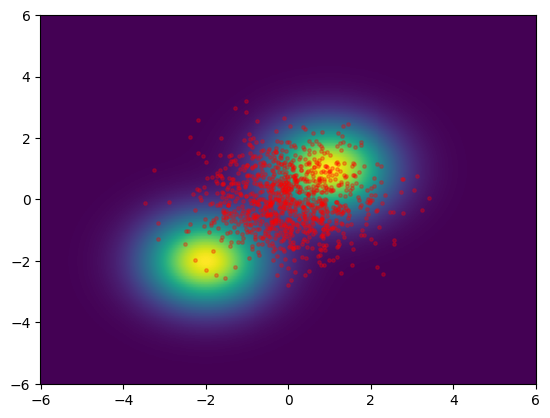

In [32]:
x = np.linspace(-6,6,500)
y = np.linspace(-6,6,500)
X, Y = np.meshgrid(x, y)
rv = sp.multivariate_normal(mean=np.ones(2))
rv2 = sp.multivariate_normal(mean= -2*np.ones(2))
fig, ax = plt.subplots()
xx = np.hstack([X.flatten().reshape(-1,1), Y.flatten().reshape(-1,1)])
ax.pcolormesh(X, Y, 0.5*rv.pdf(np.dstack((X,Y))) + 0.5*rv2.pdf(np.dstack((X,Y))))
Z= np.random.normal( size = (1000, 2))
plt.scatter(Z[:,0], Z[:,1],  s =6, c = 'red', alpha = 0.3)

In [46]:
pdf =  0.5*rv.pdf(np.dstack((X,Y))) + 0.5*rv2.pdf(np.dstack((X,Y)))
pdf.shape

(500, 500)

In [34]:
import matplotlib

In [66]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("Sequential", [ '#80ef80', 'green', "limegreen", 'yellow', 'orange'])


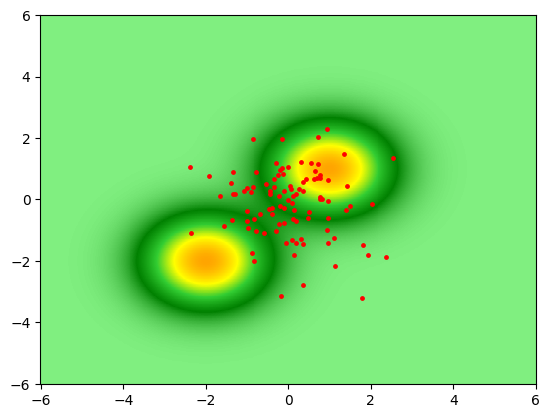

In [73]:
plt.pcolormesh(X, Y, pdf, cmap=cmap)
Z= np.random.normal( size = (100, 2))
plt.scatter(Z[:,0], Z[:,1],  s =6, c = 'red')

In [45]:
with open('txtfiles/my_file.txt', 'a') as f:
    print('le taux est de 0.3', file=f)
    print('et oui', file=f)

In [40]:
dim_20 = np.load('Resultats/Dim_20.npz')
ratio = np.exp(dim_20['arr_2'])

In [41]:
dim_20['arr_1']

array([0.34938, 0.26107, 0.22772, 0.19769, 0.18261])

In [58]:
dim_20['arr_0'].shape

(5, 10000, 20)

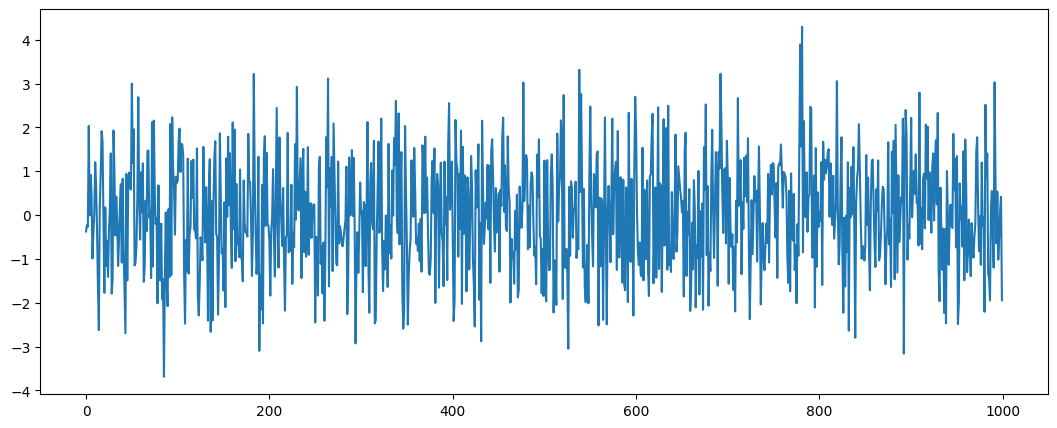

In [64]:
L  = dim_20['arr_0'][4]
plt.figure(figsize=(13,5))
plt.plot(L[1000:2000, 3]) 

In [42]:
for i in range(ratio.shape[0]):
    print(ratio[0][ratio[i]  <3].shape)

In [39]:
(ratio[3]<1).sum()

IndexError: index 3 is out of bounds for axis 0 with size 0

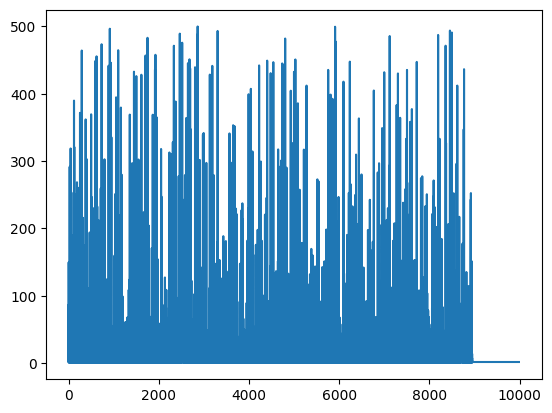

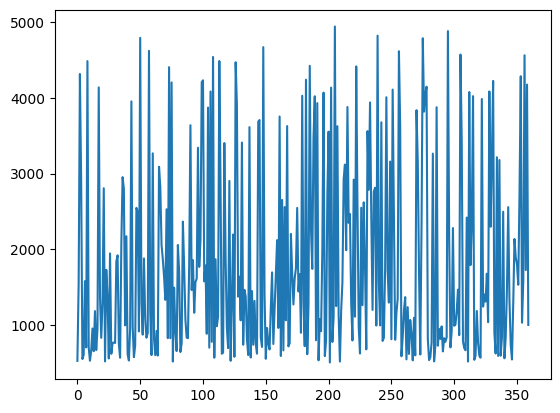

In [7]:
plt.plot(ratio[0][ratio[0] < 500])
plt.hlines(1, 0, (ratio[0] < 500).shape)
plt.show()
plt.plot(ratio[0][(ratio[0] > 500) * (ratio[0] < 5000) ])

In [69]:
b = np.zeros((5,3))
b[0] = [1,2,3]
arr, counts = np.unique(b, return_counts=True, axis=0)
print(arr,
counts)

[[0. 0. 0.]
 [1. 2. 3.]] [4 1]


(0.0, 15.0)

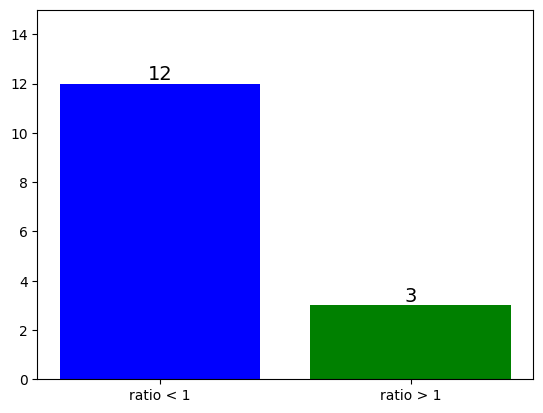

In [25]:
fig, ax = plt.subplots()

bar_container = ax.bar(['ratio < 1', 'ratio > 1'], [12, 3], color =['blue', 'green'] , label = [1,2])
ax.bar_label(bar_container, fontsize=14)
ax.set_ylim(0,15)


In [20]:
failure_zone = np.array([True, True , False, False, True, False])
~np.array(failure_zone)
candidat = np.zeros((10,3, 1))
np.repeat(candidat, 3, axis=2)
candidat[3:, [True, False, False], :]
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [16]:
u = np.ones(10)-0.3
ratio = np.random.uniform(size = 10)
liste = np.where(u < ratio)[0]
liste

array([7], dtype=int64)

In [31]:
np.random.seed(123)
candidat = np.random.normal(size = (10,3))
repeated = np.repeat(np.expand_dims(candidat, axis=0), (25-0-1), axis=0)
repeated.shape

(24, 10, 3)

In [7]:
idx = np.array([1, 2, 3, 4, 5])
idx_failure = np.array([3, 5])
idx_set = set(idx)
failure_set = set(idx_failure)

In [9]:
idx_set.intersection(failure_set)
[i for i,val in enumerate(idx_set) if val in failure_set]

[2, 4]

In [5]:
def get_matching_larger_indices(idx, idx_failure):
  """
  Finds indices in idx that are also in idx_failure and have a larger size in idx.

  Args:
      idx: A numpy array of indices.
      idx_failure: A numpy array of indices (potentially smaller than idx).

  Returns:
      A numpy array of indices from idx that are also in idx_failure and have 
      a larger size in idx.
  """
  # Convert idx and idx_failure to sets for efficient membership testing
  idx_set = set(idx)
  failure_set = set(idx_failure)

  # Find elements in idx_failure that are also in idx and get their indices in idx
  matching_indices = [i for i, val in enumerate(idx_set) if val in failure_set and i < len(idx) - 1]
  
  return np.array(matching_indices)

In [6]:
matching_indices = get_matching_larger_indices(idx, idx_failure)
matching_indices

array([2])

In [34]:
9/25

0.36